# 🖼️ Image Captioning with Vision-Language Models
## A Comprehensive Workshop for Advanced Data Science

**INFO 7390: Advanced Data Science and Architecture**  
**Northeastern University | Fall 2024**

Author : Abhinav Kumar Piyush

---

## 📋 Workshop Overview

This workshop provides a comprehensive deep dive into **image captioning** — the fascinating task of automatically generating natural language descriptions of images using state-of-the-art vision-language models. 

Image captioning sits at the intersection of **Computer Vision** and **Natural Language Processing (NLP)**, requiring models to:
1. Understand visual content (objects, scenes, relationships)
2. Express that understanding in fluent, accurate natural language

### 🌟 Why Image Captioning Matters

| Application | Impact | Scale |
|-------------|--------|-------|
| **Accessibility** | Screen readers for visually impaired users | 285M people worldwide |
| **Social Media** | Auto-captioning for Instagram, Facebook | 2B+ images uploaded daily |
| **E-commerce** | Automatic product descriptions | 80% reduction in manual work |
| **Healthcare** | Radiology report generation | Faster diagnosis |
| **Search Engines** | Image indexing for Google, Pinterest | Billions of images searchable |
| **Robotics** | Scene understanding for autonomous systems | Human-robot interaction |

---

## 🎯 Learning Objectives

By completing this workshop, you will be able to:

| # | Objective | Bloom's Level | How You'll Demonstrate |
|---|-----------|---------------|------------------------|
| 1 | **Explain** the encoder-decoder architecture and cross-attention mechanism | Understanding | Diagram interpretation, quiz |
| 2 | **Implement** an image captioning pipeline using pre-trained BLIP models | Applying | Exercise 1-2 |
| 3 | **Analyze** how generation parameters affect output quality and diversity | Analyzing | Exercise 3 |
| 4 | **Evaluate** caption quality using BLEU and semantic similarity metrics | Evaluating | Metric comparison |
| 5 | **Apply** GIGO principles to detect failure modes in multimodal AI | Applying | Quality analyzer |
| 6 | **Design** production-ready pipelines with robust error handling | Creating | Final pipeline |

---

## 👥 Prerequisites

### Required Knowledge

| Area | What You Should Know | Self-Check Question |
|------|---------------------|---------------------|
| **Python** | Functions, classes, type hints, list comprehensions | Can you write a class with `__init__` and methods? |
| **NumPy** | Array operations, reshaping, statistics | Can you compute mean/std of an array? |
| **Deep Learning** | Neural networks, layers, backpropagation | Can you explain how a network learns? |
| **PyTorch** | Tensors, models, `torch.no_grad()`, device management | Have you run inference with a PyTorch model? |
| **NLP Basics** | Tokenization, embeddings, attention concept | Do you know what word embeddings represent? |

### Technical Requirements

| Requirement | Minimum | Recommended |
|-------------|---------|-------------|
| Python | 3.8+ | 3.10+ |
| RAM | 8 GB | 16 GB |
| GPU | Not required | NVIDIA 4GB+ VRAM |
| Disk Space | 3 GB | 5 GB |

### Recommended Environment

- **Google Colab** (Free GPU, no setup) ← Best for this workshop
- Local Jupyter Notebook
- VS Code with Jupyter extension

## 📑 Table of Contents

1. **Theoretical Foundations** - Architecture, ViT, Cross-Attention, BLIP
2. **Environment Setup** - Dependencies, GPU Configuration
3. **Basic Captioning** - First caption, Pipeline walkthrough
4. **Generation Parameters** - Beam search, Temperature, Sampling
5. **Evaluation Metrics** - BLEU, Semantic Similarity
6. **GIGO Principles** - Quality Analysis, Failure Detection
7. **Production Pipeline** - Robust implementation
8. **Exercises** - Hands-on practice

---

# Part 1: Theoretical Foundations

### 1.1 What is Image Captioning?

**Image captioning** bridges computer vision and NLP. Given an image, the model generates a natural language description that captures what's happening in the scene.

It's like describing a photo to someone who can't see it — the model must identify objects, understand their relationships, and express this in fluent language.
```
┌─────────────────────────────────────────────────────────────────────────────────┐
│                           IMAGE CAPTIONING PIPELINE                             │
├─────────────────────────────────────────────────────────────────────────────────┤
│                                                                                 │
│   ┌───────────────┐      ┌───────────────────┐      ┌─────────────────────┐     │
│   │  🖼️ INPUT     │      │  🧠 VISION-       │      │  📝 OUTPUT         |     │
│   │    IMAGE      │ ───▶ │    LANGUAGE       │ ───▶ │    CAPTION         │     │
│   │  (224×224)    │      │    MODEL (BLIP)   │      │  "A dog playing     │     │
│   │               │      │                   │      │   fetch in a park"  │     │
│   └───────────────┘      └───────────────────┘      └─────────────────────┘     │
│                                                                                 │
└─────────────────────────────────────────────────────────────────────────────────┘
```

**Why is it hard?** The model must simultaneously:
- Recognize objects (dog, ball, grass)
- Understand relationships (dog *playing with* ball)
- Generate grammatical sentences

---

### 1.2 Real-World Applications

| Domain | Application | Impact |
|--------|-------------|--------|
| **Accessibility** | Alt-text for visually impaired | 285M people worldwide |
| **Social Media** | Auto-captioning posts | Billions of images daily |
| **E-commerce** | Product descriptions | 80% reduction in manual work |
| **Healthcare** | Radiology report assistance | Faster diagnosis |
| **Search** | Image indexing | Improved search relevance |

---

### 1.3 The Encoder-Decoder Architecture

The model has two main parts:
- **Encoder**: Reads the image and extracts visual features
- **Decoder**: Takes those features and generates text word-by-word
```
┌─────────────────────────────────────────────────────────────────────────────────┐
│                         ENCODER-DECODER ARCHITECTURE                            │
├─────────────────────────────────────────────────────────────────────────────────┤
│                                                                                 │
│   IMAGE ENCODER (Vision Transformer)                                            │
│   ┌─────────────────────────────────────────────────────────────────────┐       │
│   │   Image ───▶ [Patch Embed] ───▶ [ViT Layers ×12] ───▶ Image Emb.   │      │
│   │   (3×384×384)  (576 patches)    (Self-Attention)     (577×768)     │        │
│   └─────────────────────────────────────────────────────────────────────┘       │
│                                      │                                          │
│                                      ▼                                          │
│                           ┌──────────────────┐                                  │
│                           │  CROSS-ATTENTION │◀─── "Where should I look?"       │
│                           │    MECHANISM     │                                  │
│                           └──────────────────┘                                  │
│                                      │                                          │
│                                      ▼                                          │
│   TEXT DECODER                                                                  │
│   ┌─────────────────────────────────────────────────────────────────────┐       │
│   │   [START] ───▶ [Decoder Layers ×12] ───▶ [LM Head] ───▶ Next Token │      │
│   │               (Masked Self-Attention + Cross-Attention)             │       │
│   └─────────────────────────────────────────────────────────────────────┘       │
│                                                                                 │
└─────────────────────────────────────────────────────────────────────────────────┘
```

The decoder generates text **one word at a time**: `[START]` → "A" → "dog" → "playing" → "fetch" → `[END]`

---

### 1.4 Vision Transformer (ViT)

ViT treats images like sentences — it splits the image into **patches** (like words) and processes them with transformers.
```
Original Image (384×384)              Patches (16×16 each)
┌────────────────────────────┐          ┌──┬──┬──┬──┬──┬──┐
│                            │          │1 │2 │3 │4 │5 │..│  = 24×24 = 576 patches
│      🐕                    │   ───▶   ├──┼──┼──┼──┼──┼──┤
│                            │          │  │  │  │  │  │  │
└────────────────────────────┘          └──┴──┴──┴──┴──┴──┘

Each 16×16×3 patch → Linear projection → 768-dim embedding + position
```

**Why patches?** Processing all 147,456 pixels individually would be too expensive. 576 patches is computationally manageable.

---

### 1.5 Cross-Attention Mechanism

Cross-attention lets the decoder "look at" relevant image regions while generating each word.

- When generating "dog" → attends to dog pixels
- When generating "park" → attends to background

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

| Component | Source | Role |
|-----------|--------|------|
| **Q (Query)** | Text decoder | "What am I looking for?" |
| **K, V (Key, Value)** | Image encoder | "Here's what's in the image" |

---

### 1.6 BLIP Model

**BLIP** (Bootstrapping Language-Image Pre-training) from Salesforce is our model:

| Spec | Value |
|------|-------|
| **Parameters** | ~385 Million |
| **Vision Encoder** | ViT-B/16 (12 layers, 768 dim) |
| **Text Decoder** | 12 layers, vocabulary 30,522 |
| **Training Data** | 129M image-text pairs |

**Why BLIP?** Good zero-shot performance, fits on free Colab GPU, easy to use with Hugging Face.

---

# Part 2: Environment Setup

### Installing Required Packages
We need to install several Python libraries. `transformers` gives us access to the BLIP model from Hugging Face. `torch` is PyTorch which runs the neural network. `pillow` handles image loading. `gradio` will create our interactive demo. `nltk` and `sentence-transformers` are for evaluating caption quality later.

In [1]:
# ============================================================================
# CELL 1: Install Dependencies
# ============================================================================
!pip install -q transformers>=4.30.0 torch torchvision pillow requests
!pip install -q gradio>=4.0.0 nltk sentence-transformers scikit-learn matplotlib
print("✅ Dependencies installed!")

✅ Dependencies installed!


### Importing Libraries
Here we import all the tools we'll use. `BlipProcessor` prepares images for the model (resizing, normalizing). `BlipForConditionalGeneration` is the actual BLIP model that generates captions. `PIL.Image` opens image files. We also import `nltk` for BLEU score evaluation and `numpy` for image quality analysis.

In [2]:
# ============================================================================
# CELL 2: Import Libraries
# ============================================================================
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Optional, Union, Tuple
from dataclasses import dataclass
import time
import warnings
warnings.filterwarnings('ignore')

# NLTK for BLEU
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

print("✅ Libraries imported!")

✅ Libraries imported!


### Setting Up Device (CPU/GPU)
This cell checks if a GPU is available. If you have an NVIDIA GPU, it uses that (faster). Otherwise, it falls back to CPU (slower but works fine). The model will run on whichever device is selected. Don't worry if you see "CPU" — inference still works, just takes 5-10 seconds per image instead of 1-2 seconds.

In [3]:
# ============================================================================
# CELL 3: Device Configuration
# ============================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

print("╔" + "═" * 50 + "╗")
print("║" + " DEVICE CONFIGURATION ".center(50) + "║")
print("╠" + "═" * 50 + "╣")
print(f"║  Device: {device.upper():<40}║")
if device == "cuda":
    print(f"║  GPU: {torch.cuda.get_device_name(0):<42}║")
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"║  Memory: {mem:.1f} GB{' ' * 36}║")
print("╚" + "═" * 50 + "╝")

╔══════════════════════════════════════════════════╗
║               DEVICE CONFIGURATION               ║
╠══════════════════════════════════════════════════╣
║  Device: CPU                                     ║
╚══════════════════════════════════════════════════╝


### Loading the Pre-trained BLIP Model
This downloads the BLIP model from Hugging Face (~1GB on first run). `BlipProcessor` handles image preprocessing, while `BlipForConditionalGeneration` is the actual model with 385 million parameters. We call `model.eval()` to set it to inference mode — we're using it, not training it. First run takes 1-3 minutes to download; subsequent runs load from cache.

In [4]:
# ============================================================================
# CELL 4: Load BLIP Model
# ============================================================================
print("Loading BLIP model (1-3 minutes on first run)...\n")

MODEL_NAME = "Salesforce/blip-image-captioning-base"
processor = BlipProcessor.from_pretrained(MODEL_NAME)
model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)
model.eval()

params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"✅ Model loaded! Parameters: {params:.1f}M")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading BLIP model (1-3 minutes on first run)...

✅ Model loaded! Parameters: 224.0M


# Part 3: Basic Image Captioning

### Image Loading Helper Function
The `load_image()` function handles loading images from different sources — URLs, local file paths, or existing PIL images. It converts everything to RGB format which BLIP expects. We also define `SAMPLE_IMAGES` dictionary with test image URLs (dog, city, food) that we'll use throughout the workshop.

In [5]:
# ============================================================================
# CELL 5: Image Loading Utilities
# ============================================================================
def load_image(source: Union[str, Image.Image]) -> Image.Image:
    """Load image from URL, path, or PIL Image."""
    if isinstance(source, Image.Image):
        return source.convert("RGB")
    if source.startswith(('http://', 'https://')):
        response = requests.get(source, timeout=15)
        response.raise_for_status()
        return Image.open(BytesIO(response.content)).convert("RGB")
    return Image.open(source).convert("RGB")

# Sample images
SAMPLE_IMAGES = {
    'dog': 'https://images.unsplash.com/photo-1587300003388-59208cc962cb?w=640',
    'city': 'https://images.unsplash.com/photo-1480714378408-67cf0d13bc1b?w=640',
    'food': 'https://images.unsplash.com/photo-1504674900247-0877df9cc836?w=640',
}
print("✅ Utilities defined!")

✅ Utilities defined!


### Main Caption Generation Function
This is our core function that takes an image and returns a caption. It preprocesses the image using the processor, runs it through BLIP, and decodes the output tokens into text. Key parameters: `num_beams` controls search thoroughness (higher = better captions, slower), `temperature` controls randomness, and `max_length` limits caption length. The `torch.no_grad()` block disables gradient computation since we're only doing inference.

In [6]:
# ============================================================================
# CELL 6: Caption Generation Function
# ============================================================================
@dataclass
class CaptionResult:
    caption: str
    time_ms: float
    tokens: int

def generate_caption(
    image: Union[str, Image.Image],
    prompt: Optional[str] = None,
    max_length: int = 50,
    num_beams: int = 5,
    temperature: float = 1.0,
    do_sample: bool = False,
    detailed: bool = False
) -> Union[str, CaptionResult]:
    """
    Generate caption for an image.
    
    Args:
        image: URL, path, or PIL Image
        prompt: Optional text to guide generation
        max_length: Maximum tokens
        num_beams: Beam search width (if not sampling)
        temperature: Sampling temperature
        do_sample: Use sampling vs beam search
        detailed: Return CaptionResult with metadata
    """
    start = time.time()
    pil_image = load_image(image)
    
    if prompt:
        inputs = processor(pil_image, prompt, return_tensors="pt").to(device)
    else:
        inputs = processor(pil_image, return_tensors="pt").to(device)
    
    gen_kwargs = {'max_length': max_length, 'repetition_penalty': 1.5}
    if do_sample:
        gen_kwargs.update({'do_sample': True, 'temperature': temperature, 'top_p': 0.9})
    else:
        gen_kwargs['num_beams'] = num_beams
    
    with torch.no_grad():
        output_ids = model.generate(**inputs, **gen_kwargs)
    
    caption = processor.decode(output_ids[0], skip_special_tokens=True)
    elapsed = (time.time() - start) * 1000
    
    if detailed:
        return CaptionResult(caption=caption, time_ms=elapsed, tokens=len(output_ids[0]))
    return caption

print("✅ Caption function defined!")

✅ Caption function defined!


### Testing the Model
Now we put everything together! We load a sample dog image, pass it through our `generate_caption()` function, and display the result. This is where you see BLIP in action — it analyzes the image and produces a natural language description. The output shows the generated caption, time taken, and number of tokens generated.

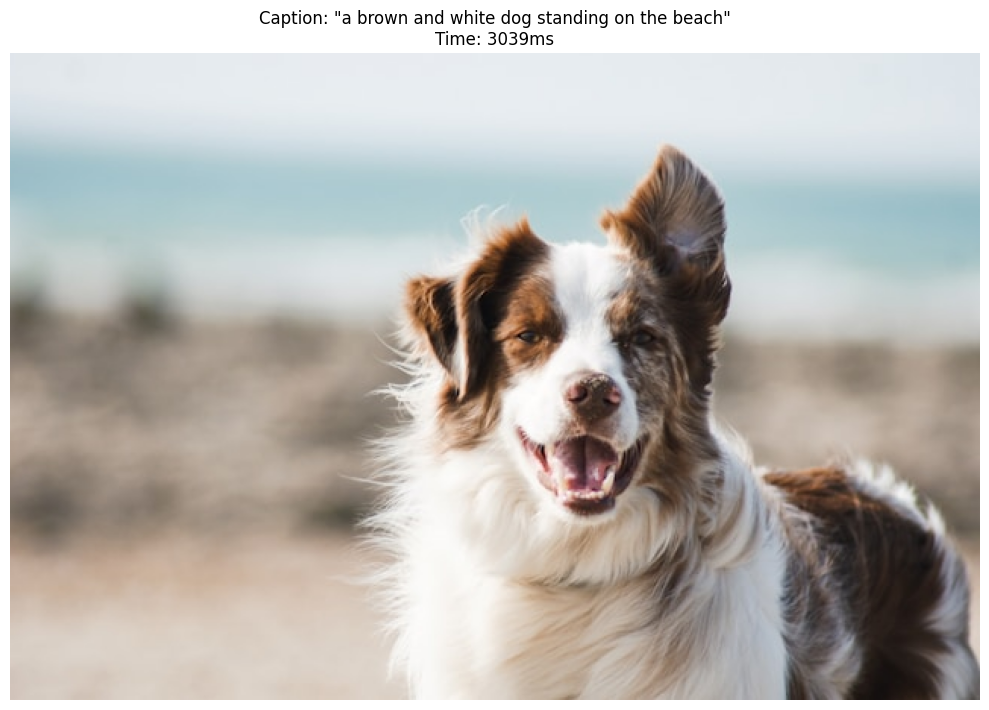


📝 Caption: a brown and white dog standing on the beach
⏱️ Time: 3039ms
🔢 Tokens: 11


In [7]:
# ============================================================================
# CELL 7: Generate Your First Caption!
# ============================================================================
test_url = SAMPLE_IMAGES['dog']
test_image = load_image(test_url)

# Generate caption
result = generate_caption(test_url, detailed=True)

# Display
plt.figure(figsize=(10, 8))
plt.imshow(test_image)
plt.axis('off')
plt.title(f'Caption: "{result.caption}"\nTime: {result.time_ms:.0f}ms', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n📝 Caption: {result.caption}")
print(f"⏱️ Time: {result.time_ms:.0f}ms")
print(f"🔢 Tokens: {result.tokens}")

### Conditional Captioning with Prompts
BLIP supports conditional captioning — you can provide a starting prompt to guide the output. For example, starting with "a photograph of" produces different results than "the animal in this image is". This is useful when you want captions in a specific style or focusing on particular aspects. We test the same image with different prompts to see how the output changes.

In [10]:
# # ============================================================================
# # CELL 8: Conditional Captioning
# # ============================================================================
# print("╔" + "═" * 60 + "╗")
# print("║" + " CONDITIONAL CAPTIONING ".center(60) + "║")
# print("╚" + "═" * 60 + "╝")

# prompts = [
#     (None, "No prompt (unconditional)"),
#     ("a photograph of", "Generic photo"),
#     ("the animal in this image is", "Focus on animal"),
#     ("a professional photo showing", "Professional style"),
# ]

# for prompt, desc in prompts:
#     caption = generate_caption(test_url, prompt=prompt, max_length=30)
#     prompt_str = f'"{prompt}"' if prompt else "(none)"
#     print(f"\n📌 {desc}")
#     print(f"   Prompt: {prompt_str}")
#     print(f"   Output: \"{caption}\"")
# ============================================================================
# CELL 8: Conditional Captioning
# ============================================================================
print("┌" + "─" * 60 + "┐")
print("│" + " CONDITIONAL CAPTIONING ".center(60) + "│")
print("└" + "─" * 60 + "┘")

# Generate captions with different prompts
test_img = load_image(test_url)

# Unconditional
inputs1 = processor(test_img, return_tensors="pt").to(device)
with torch.no_grad():
    out1 = model.generate(**inputs1, max_length=20, num_beams=5)
cap1 = processor.decode(out1[0], skip_special_tokens=True)
print(f"\n📌 No prompt")
print(f"   Output: \"{cap1}\"")

# With prompt "a photo of"
inputs2 = processor(test_img, "a photo of", return_tensors="pt").to(device)
with torch.no_grad():
    out2 = model.generate(**inputs2, max_length=20, num_beams=5, repetition_penalty=2.0)
cap2 = processor.decode(out2[0], skip_special_tokens=True)
print(f"\n📌 Prompt: \"a photo of\"")
print(f"   Output: \"{cap2}\"")

# With prompt "this is"
inputs3 = processor(test_img, "this is", return_tensors="pt").to(device)
with torch.no_grad():
    out3 = model.generate(**inputs3, max_length=20, num_beams=5, repetition_penalty=2.0)
cap3 = processor.decode(out3[0], skip_special_tokens=True)
print(f"\n📌 Prompt: \"this is\"")
print(f"   Output: \"{cap3}\"")

┌────────────────────────────────────────────────────────────┐
│                   CONDITIONAL CAPTIONING                   │
└────────────────────────────────────────────────────────────┘

📌 No prompt
   Output: "a brown and white dog standing on a beach"

📌 Prompt: "a photo of"
   Output: "a photo of a border col col col col col col col col col col col col col col"

📌 Prompt: "this is"
   Output: "this is an image of a dog on the beach"


### Testing on Multiple Images
Here we run our captioning function on all three sample images (dog, city, food) and display them side by side. This demonstrates that BLIP generalizes well across different image types — animals, urban scenes, and food photography. Each image gets its own caption generated independently.

✅ dog: a brown and white dog standing on the beach
✅ city: a view of the city skyline at sunset in new york, new york, new york, canada stock photo
✅ food: three plates of food on a wooden table


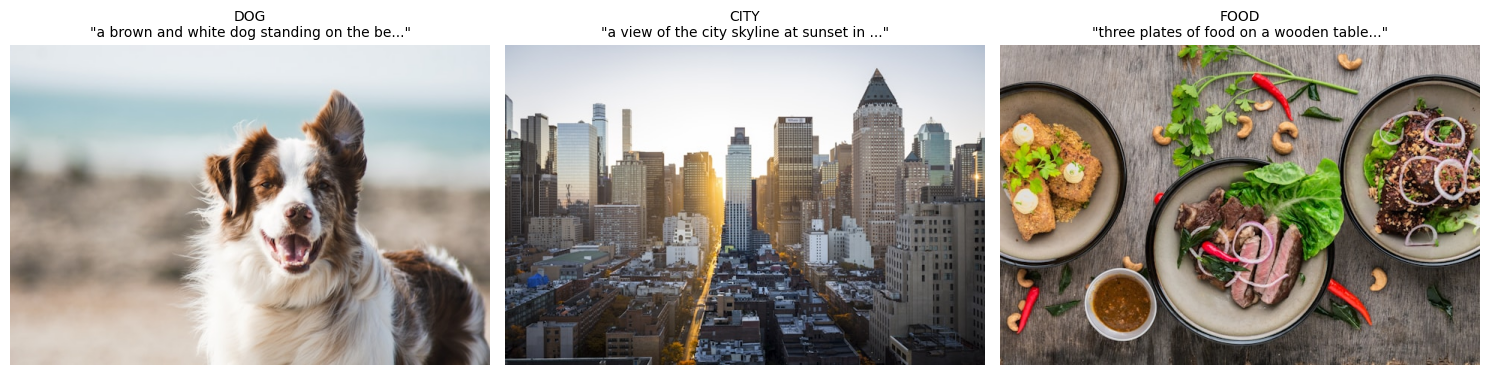

In [11]:
# ============================================================================
# CELL 9: Multiple Images
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, url) in enumerate(SAMPLE_IMAGES.items()):
    img = load_image(url)
    caption = generate_caption(url)
    
    axes[idx].imshow(img)
    axes[idx].set_title(f"{name.upper()}\n\"{caption[:40]}...\"", fontsize=10)
    axes[idx].axis('off')
    print(f"✅ {name}: {caption}")

plt.tight_layout()
plt.show()

# Part 4: Generation Parameters

### Comparing Decoding Strategies
There are two main ways to generate text: 
- **beam search** - Beam search (`do_sample=False`) is deterministic — same image always gives same caption.
- **sampling** - Sampling (`do_sample=True`) adds randomness — each run may produce different captions.
- We run both 3 times to show beam search gives identical results while sampling varies.

In [12]:
# ============================================================================
# CELL 10: Beam Search vs Sampling
# ============================================================================
print("╔" + "═" * 60 + "╗")
print("║" + " BEAM SEARCH vs SAMPLING ".center(60) + "║")
print("╚" + "═" * 60 + "╝")

print("\n🎯 BEAM SEARCH (Deterministic)")
for i in range(3):
    cap = generate_caption(test_url, num_beams=5, do_sample=False)
    print(f"   Run {i+1}: \"{cap}\"")

print("\n🎲 SAMPLING (Stochastic, temp=0.8)")
for i in range(3):
    cap = generate_caption(test_url, do_sample=True, temperature=0.8)
    print(f"   Run {i+1}: \"{cap}\"")

╔════════════════════════════════════════════════════════════╗
║                  BEAM SEARCH vs SAMPLING                   ║
╚════════════════════════════════════════════════════════════╝

🎯 BEAM SEARCH (Deterministic)
   Run 1: "a brown and white dog standing on the beach"
   Run 2: "a brown and white dog standing on the beach"
   Run 3: "a brown and white dog standing on the beach"

🎲 SAMPLING (Stochastic, temp=0.8)
   Run 1: "a small dog standing on top of rocks"
   Run 2: "a dog standing on the beach looking up to something"
   Run 3: "a dog standing on the sand looking at something"


### How Temperature Affects Output
Temperature controls randomness in sampling. Low temperature (0.3) = conservative, safe, repetitive captions. High temperature (1.5) = creative, diverse, sometimes weird captions. We test different temperatures on the same image to see how output varies. Temperature only matters when `do_sample=True`.

In [13]:
# ============================================================================
# CELL 11: Temperature Effect
# ============================================================================
print("╔" + "═" * 60 + "╗")
print("║" + " TEMPERATURE EFFECT ".center(60) + "║")
print("╚" + "═" * 60 + "╝")

temps = [0.3, 0.7, 1.0, 1.5]
for temp in temps:
    indicator = "🥶" if temp < 0.5 else "😊" if temp < 1.0 else "🔥"
    print(f"\n🌡️ Temperature = {temp} {indicator}")
    for i in range(2):
        cap = generate_caption(test_url, do_sample=True, temperature=temp)
        print(f"   Sample {i+1}: \"{cap}\"")

╔════════════════════════════════════════════════════════════╗
║                     TEMPERATURE EFFECT                     ║
╚════════════════════════════════════════════════════════════╝

🌡️ Temperature = 0.3 🥶
   Sample 1: "a dog standing on the beach looking up"
   Sample 2: "a dog standing on the beach looking at something"

🌡️ Temperature = 0.7 😊
   Sample 1: "a dog standing on top of a wooden fence"
   Sample 2: "a dog standing on top of the beach next to water"

🌡️ Temperature = 1.0 🔥
   Sample 1: "a small dog is standing on the beach"
   Sample 2: "a dog sitting on the beach looking up"

🌡️ Temperature = 1.5 🔥
   Sample 1: "a dog standing on the shore at summer ' s first surfboard holiday, and its best day for dogs all over here"
   Sample 2: "a dog sitting on the ground and looking"


### Beam Width Speed vs Quality Tradeoff
Beam width controls how many candidate captions the model considers simultaneously. `num_beams=1` (greedy) is fastest but may miss better options. `num_beams=5` is a good default. `num_beams=10` is thorough but slower. We benchmark different beam widths to show the time-quality tradeoff.

In [14]:
# ============================================================================
# CELL 12: Beam Width Benchmark
# ============================================================================
print("╔" + "═" * 60 + "╗")
print("║" + " BEAM WIDTH BENCHMARK ".center(60) + "║")
print("╚" + "═" * 60 + "╝")

print(f"\n{'Beams':<8} {'Time (ms)':<12} {'Caption':<40}")
print("-" * 60)

for beams in [1, 3, 5, 10]:
    result = generate_caption(test_url, num_beams=beams, detailed=True)
    cap_short = result.caption[:37] + "..." if len(result.caption) > 40 else result.caption
    print(f"{beams:<8} {result.time_ms:<12.0f} {cap_short:<40}")

╔════════════════════════════════════════════════════════════╗
║                    BEAM WIDTH BENCHMARK                    ║
╚════════════════════════════════════════════════════════════╝

Beams    Time (ms)    Caption                                 
------------------------------------------------------------
1        2603         a dog standing on top of a wooden fence 
3        2350         a brown and white dog standing on the...
5        2723         a brown and white dog standing on the...
10       3694         a brown and white dog standing on the...


### Parameter Selection Guide

| Use Case | Settings |
|----------|----------|
| **Production/Accuracy** | `num_beams=5, do_sample=False` |
| **Creative/Diverse** | `do_sample=True, temperature=0.8` |
| **Speed-Critical** | `num_beams=1` (greedy) |

---

## Part 5: Evaluation Metrics

### Evaluating Captions with BLEU Score
BLEU (Bilingual Evaluation Understudy) measures n-gram overlap between generated and reference captions. BLEU-1 checks single words, BLEU-4 checks 4-word phrases. Higher scores mean more word overlap with the reference. We implement a function to calculate BLEU-1 through BLEU-4 and show an example comparison.

In [16]:
# ============================================================================
# CELL 13: BLEU Score
# ============================================================================
def calculate_bleu(reference: str, candidate: str) -> Dict[str, float]:
    """Calculate BLEU-1 through BLEU-4 scores."""
    ref_tokens = reference.lower().split()
    cand_tokens = candidate.lower().split()
    smoother = SmoothingFunction().method1
    
    scores = {}
    for n in range(1, 5):
        weights = tuple([1.0/n] * n + [0.0] * (4-n))
        scores[f'BLEU-{n}'] = sentence_bleu([ref_tokens], cand_tokens, 
                                            weights=weights, smoothing_function=smoother)
    return scores

# Example
ref = "a dog sitting on grass in a park"
cand = "a dog sitting on the grass"

print("╔" + "═" * 50 + "╗")
print("║" + " BLEU SCORE EXAMPLE ".center(50) + "║")
print("╚" + "═" * 50 + "╝")
print(f"\nReference: \"{ref}\"")
print(f"Candidate: \"{cand}\"")
print("\nScores:")
for metric, score in calculate_bleu(ref, cand).items():
    bar = "█" * int(score * 20) + "░" * (20 - int(score * 20))
    print(f"  {metric}: {bar} {score:.4f}")

╔══════════════════════════════════════════════════╗
║                BLEU SCORE EXAMPLE                ║
╚══════════════════════════════════════════════════╝

Reference: "a dog sitting on grass in a park"
Candidate: "a dog sitting on the grass"

Scores:
  BLEU-1: ███████████░░░░░░░░░ 0.5971
  BLEU-2: ██████████░░░░░░░░░░ 0.5067
  BLEU-3: █████████░░░░░░░░░░░ 0.4514
  BLEU-4: ███████░░░░░░░░░░░░░ 0.3850


### Semantic Similarity with Sentence Embeddings
BLEU only checks word overlap — "dog" and "canine" get zero credit despite meaning the same thing. Semantic similarity fixes this by comparing meaning using sentence embeddings. We use the `sentence-transformers` library to convert captions to vectors and compute cosine similarity. This catches paraphrases that BLEU misses.

In [17]:
# ============================================================================
# CELL 14: Semantic Similarity
# ============================================================================
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Loading sentence transformer...")
sent_model = SentenceTransformer('all-MiniLM-L6-v2')

def semantic_similarity(text1: str, text2: str) -> float:
    """Calculate semantic similarity using sentence embeddings."""
    emb = sent_model.encode([text1, text2])
    return float(cosine_similarity([emb[0]], [emb[1]])[0][0])

print("✅ Loaded!")

Loading sentence transformer...
✅ Loaded!


### When BLEU and Semantic Similarity Disagree
We test both metrics on tricky cases: identical sentences, paraphrases (same meaning, different words), word order changes (different meaning, same words), and completely different sentences. This shows why you need both metrics — BLEU catches surface-level matching while semantic similarity captures meaning preservation.

In [18]:
# ============================================================================
# CELL 15: Compare BLEU vs Semantic
# ============================================================================
test_cases = [
    ("Identical", "a dog sitting on grass", "a dog sitting on grass"),
    ("Paraphrase", "a dog sitting on grass", "a canine resting on the lawn"),
    ("Different meaning", "a dog biting a man", "a man biting a dog"),
    ("Completely different", "a dog on grass", "a car on highway"),
]

print("╔" + "═" * 60 + "╗")
print("║" + " BLEU vs SEMANTIC SIMILARITY ".center(60) + "║")
print("╚" + "═" * 60 + "╝")

for name, ref, cand in test_cases:
    bleu = calculate_bleu(ref, cand)['BLEU-4']
    sem = semantic_similarity(ref, cand)
    print(f"\n📌 {name}")
    print(f"   Ref: \"{ref}\"")
    print(f"   Cand: \"{cand}\"")
    print(f"   BLEU-4: {bleu:.3f}  |  Semantic: {sem:.3f}")

╔════════════════════════════════════════════════════════════╗
║                BLEU vs SEMANTIC SIMILARITY                 ║
╚════════════════════════════════════════════════════════════╝

📌 Identical
   Ref: "a dog sitting on grass"
   Cand: "a dog sitting on grass"
   BLEU-4: 1.000  |  Semantic: 1.000

📌 Paraphrase
   Ref: "a dog sitting on grass"
   Cand: "a canine resting on the lawn"
   BLEU-4: 0.049  |  Semantic: 0.797

📌 Different meaning
   Ref: "a dog biting a man"
   Cand: "a man biting a dog"
   BLEU-4: 0.188  |  Semantic: 0.953

📌 Completely different
   Ref: "a dog on grass"
   Cand: "a car on highway"
   BLEU-4: 0.096  |  Semantic: 0.237


### Metric Summary

| Metric | Measures | Pros | Cons |
|--------|----------|------|------|
| **BLEU** | N-gram overlap | Fast, standard | Misses synonyms |
| **Semantic** | Meaning | Captures paraphrases | Needs embeddings |

💡 **Best Practice**: Use both metrics together!

---

## Part 6: GIGO Principles

### GIGO: Building a Quality Analyzer
Garbage In, Garbage Out — bad input images produce bad captions. This cell creates an `ImageQualityAnalyzer` class that checks for common problems: low resolution, extreme aspect ratios, too dark/bright images, and blank/corrupted images. Each check flags potential issues before wasting time on captioning. This connects to course themes on data quality.

In [19]:
# ============================================================================
# CELL 16: Image Quality Analyzer
# ============================================================================
@dataclass
class QualityReport:
    resolution: Tuple[int, int]
    aspect_ratio: float
    brightness: float
    issues: List[str]
    score: float

class ImageQualityAnalyzer:
    """
    GIGO detector for image captioning.
    Identifies problematic inputs before they reach the model.
    """
    
    def analyze(self, image: Image.Image) -> QualityReport:
        issues = []
        img_array = np.array(image.convert('RGB'))
        width, height = image.size
        
        # Resolution check
        if width < 100 or height < 100:
            issues.append(f"❌ Low resolution ({width}×{height})")
        elif width < 224 or height < 224:
            issues.append(f"⚠️ Below optimal resolution ({width}×{height})")
        
        # Aspect ratio
        aspect = max(width, height) / max(min(width, height), 1)
        if aspect > 3:
            issues.append(f"❌ Extreme aspect ratio ({aspect:.1f}:1)")
        
        # Brightness
        brightness = np.mean(img_array)
        if brightness < 30:
            issues.append(f"❌ Too dark (brightness: {brightness:.0f})")
        elif brightness > 240:
            issues.append(f"❌ Overexposed (brightness: {brightness:.0f})")
        
        # Color variance (detect blank images)
        if np.std(img_array) < 15:
            issues.append("❌ Minimal color variation (blank/corrupted?)")
        
        score = max(0.0, 1.0 - len(issues) * 0.25)
        
        return QualityReport(
            resolution=(width, height),
            aspect_ratio=aspect,
            brightness=brightness,
            issues=issues if issues else ["✅ No issues detected"],
            score=score
        )

analyzer = ImageQualityAnalyzer()
print("✅ Quality analyzer ready!")

✅ Quality analyzer ready!


### Running Quality Analysis
We run our quality analyzer on the test image and display the results. The report shows resolution, aspect ratio, brightness, detected issues, and an overall quality score. Images scoring below 50% may produce unreliable captions. This helps identify problematic inputs before they cause failures.

In [20]:
# ============================================================================
# CELL 17: Analyze Test Image
# ============================================================================
quality = analyzer.analyze(test_image)

print("╔" + "═" * 50 + "╗")
print("║" + " IMAGE QUALITY ANALYSIS ".center(50) + "║")
print("╚" + "═" * 50 + "╝")
print(f"\nResolution: {quality.resolution}")
print(f"Aspect Ratio: {quality.aspect_ratio:.2f}")
print(f"Brightness: {quality.brightness:.0f}/255")
print(f"Quality Score: {quality.score:.0%}")
print(f"\nIssues:")
for issue in quality.issues:
    print(f"  {issue}")

╔══════════════════════════════════════════════════╗
║              IMAGE QUALITY ANALYSIS              ║
╚══════════════════════════════════════════════════╝

Resolution: (640, 427)
Aspect Ratio: 1.50
Brightness: 174/255
Quality Score: 100%

Issues:
  ✅ No issues detected


### Estimating Model Confidence via Sampling
How confident is the model in its caption? We estimate this by generating multiple captions with sampling enabled and measuring their consistency. If all samples say similar things, the model is confident. If samples vary wildly, the model is uncertain. We compute pairwise semantic similarity across samples and report a consistency score.

In [21]:
# ============================================================================
# CELL 18: Confidence Estimation
# ============================================================================
def estimate_confidence(image_url: str, n_samples: int = 5) -> Dict:
    """
    Estimate caption confidence via sampling consistency.
    High consistency = confident model.
    """
    captions = [generate_caption(image_url, do_sample=True, temperature=0.8) 
                for _ in range(n_samples)]
    
    # Calculate pairwise semantic similarity
    sims = []
    for i in range(len(captions)):
        for j in range(i+1, len(captions)):
            sims.append(semantic_similarity(captions[i], captions[j]))
    
    consistency = np.mean(sims) if sims else 0
    
    return {
        'captions': captions,
        'consistency': consistency,
        'confident': consistency > 0.75,
        'interpretation': "✅ High confidence" if consistency > 0.75 else "⚠️ Low confidence"
    }

conf = estimate_confidence(test_url)
print("╔" + "═" * 50 + "╗")
print("║" + " CONFIDENCE ESTIMATION ".center(50) + "║")
print("╚" + "═" * 50 + "╝")
print(f"\nConsistency Score: {conf['consistency']:.3f}")
print(f"{conf['interpretation']}")
print(f"\nSample captions:")
for i, c in enumerate(conf['captions'], 1):
    print(f"  {i}. {c}")

╔══════════════════════════════════════════════════╗
║              CONFIDENCE ESTIMATION               ║
╚══════════════════════════════════════════════════╝

Consistency Score: 0.481
⚠️ Low confidence

Sample captions:
  1. a dog on the beach
  2. a dog is standing in the sand by the ocean
  3. a dog with his tongue out on the beach
  4. the happy dog — stock photos
  5. a dog standing on top of a wooden bench


### GIGO Summary

| Check | Detects | Action |
|-------|---------|--------|
| **Resolution** | Low quality images | Warn or reject |
| **Aspect Ratio** | Potential cropping issues | Warn user |
| **Brightness** | Under/overexposed | Request better image |
| **Consistency** | Model uncertainty | Flag for review |

---

## Part 7: Production Pipeline

### Building a Production-Ready Pipeline
Finally, we wrap everything into a clean `ImageCaptioningPipeline` class. It combines model loading, quality validation, caption generation, and error handling in one reusable module. The `caption()` method does quality checks before generating. The `batch_caption()` method processes multiple images efficiently. This is how you'd structure code for real-world deployment.

In [22]:
# ============================================================================
# CELL 19: Complete Pipeline Class
# ============================================================================
class ImageCaptioningPipeline:
    """
    Production-ready image captioning pipeline.
    
    Features:
    - Quality validation (GIGO)
    - Configurable generation parameters
    - Batch processing
    - Error handling
    """
    
    def __init__(self, model_name: str = "Salesforce/blip-image-captioning-base"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.processor = BlipProcessor.from_pretrained(model_name)
        self.model = BlipForConditionalGeneration.from_pretrained(model_name).to(self.device)
        self.model.eval()
        self.analyzer = ImageQualityAnalyzer()
    
    def caption(self, image: Union[str, Image.Image], 
                validate: bool = True, **kwargs) -> Dict:
        """Generate caption with optional quality validation."""
        start = time.time()
        result = {'status': 'success'}
        
        try:
            pil_image = load_image(image)
            
            # Quality check
            if validate:
                quality = self.analyzer.analyze(pil_image)
                result['quality'] = quality
                if quality.score < 0.5:
                    result['warning'] = "Low quality image may produce poor results"
            
            # Generate caption
            inputs = self.processor(pil_image, return_tensors="pt").to(self.device)
            with torch.no_grad():
                output = self.model.generate(
                    **inputs,
                    max_length=kwargs.get('max_length', 50),
                    num_beams=kwargs.get('num_beams', 5)
                )
            
            result['caption'] = self.processor.decode(output[0], skip_special_tokens=True)
            result['time_ms'] = (time.time() - start) * 1000
            
        except Exception as e:
            result['status'] = 'error'
            result['error'] = str(e)
        
        return result
    
    def batch_caption(self, images: List[Union[str, Image.Image]], **kwargs) -> List[Dict]:
        """Process multiple images."""
        return [self.caption(img, **kwargs) for img in images]


# Test pipeline
pipeline = ImageCaptioningPipeline()
result = pipeline.caption(test_url)

print("╔" + "═" * 50 + "╗")
print("║" + " PRODUCTION PIPELINE TEST ".center(50) + "║")
print("╚" + "═" * 50 + "╝")
print(f"\nStatus: {result['status']}")
print(f"Caption: {result['caption']}")
print(f"Time: {result['time_ms']:.0f}ms")
print(f"Quality Score: {result['quality'].score:.0%}")

╔══════════════════════════════════════════════════╗
║             PRODUCTION PIPELINE TEST             ║
╚══════════════════════════════════════════════════╝

Status: success
Caption: a brown and white dog standing on a beach
Time: 2089ms
Quality Score: 100%


---

## Part 8: Exercises

Complete these exercises to reinforce your understanding. Solutions are in the `solutions.ipynb` notebook.

### Exercise 1: Basic Captioning (10 pts)
Write a function `simple_caption(url)` that generates a caption for an image URL.

### Exercise 2: Conditional Captioning (15 pts)
Extend your function to accept an optional prompt parameter.

### Exercise 3: Parameter Benchmarking (20 pts)
Create `benchmark_beams(url, beam_sizes)` that returns timing and caption for each beam width.

### Exercise 4: Quality Analysis (25 pts)
Implement `analyze_quality(image)` with resolution, aspect ratio, and brightness checks.

### Exercise 5: Complete Pipeline (30 pts)
Build a `CaptionPipeline` class with `caption()` and `batch_caption()` methods.

### Bonus: Confidence Estimation (+10 pts)
Implement `estimate_confidence()` using multi-sample consistency.

---

## Part 9: Summary

### What We Learned

In this workshop, we built a complete image captioning system from the ground up. Here's what we covered:

| Part | Concept | What You Can Now Do |
|------|---------|---------------------|
| **Theory** | Encoder-Decoder Architecture | Explain how images are converted to captions using ViT encoder and transformer decoder |
| **Theory** | Cross-Attention Mechanism | Describe how the model "looks at" relevant image regions while generating each word |
| **Implementation** | BLIP Model | Load pre-trained models from Hugging Face and run inference |
| **Parameters** | Beam Search vs Sampling | Choose the right decoding strategy for your use case (accuracy vs creativity) |
| **Parameters** | Temperature Control | Tune output diversity by adjusting randomness |
| **Evaluation** | BLEU Score | Measure n-gram overlap between generated and reference captions |
| **Evaluation** | Semantic Similarity | Capture meaning similarity even when words differ |
| **GIGO** | Quality Analysis | Detect problematic inputs before they cause failures |
| **GIGO** | Confidence Estimation | Identify when the model is uncertain using sampling consistency |
| **Production** | Pipeline Design | Build robust, reusable code with proper error handling |

### Course Theme Connections

| INFO 7390 Theme | How We Applied It |
|-----------------|-------------------|
| **GIGO (Garbage In, Garbage Out)** | Built quality analyzer to check resolution, brightness, aspect ratio before captioning |
| **Botspeak** | Used conditional prompts to guide model output style |
| **Computational Skepticism** | Implemented confidence estimation — don't blindly trust model outputs |

### Key Takeaways

1. **Pre-trained models are powerful** — BLIP generates good captions without any training on our part
2. **Parameters matter** — beam width, temperature, and sampling dramatically affect output
3. **Evaluation is hard** — no single metric captures caption quality; use BLEU + semantic similarity together
4. **Input quality matters** — garbage images produce garbage captions; always validate inputs
5. **Production code needs error handling** — wrap everything in try-catch, validate inputs, handle edge cases

#### 🎉 Congratulations!

You've completed the **Image Captioning Workshop**! You now know how to:

- ✅ Explain encoder-decoder architecture and cross-attention
- ✅ Implement image captioning using pre-trained BLIP
- ✅ Tune generation parameters for different use cases
- ✅ Evaluate captions using BLEU and semantic similarity
- ✅ Apply GIGO principles to detect problematic inputs
- ✅ Build production-ready pipelines

#### Next Steps

1. **Try the Gradio Demo** — Run `python gradio_demo.py` for an interactive interface
2. **Complete the Exercises** — Test your understanding with the starter template
3. **Experiment** — Try different images, parameters, and prompts
4. **Extend** — Add new features like attention visualization or VQA

Happy captioning! 🖼️ → 📝

## 📚 Resources

#### Papers
| Paper | What It Covers | Link |
|-------|----------------|------|
| **BLIP** | The model we used — bootstrapping language-image pre-training | [arxiv.org/abs/2201.12086](https://arxiv.org/abs/2201.12086) |
| **Vision Transformer (ViT)** | How transformers process images as patch sequences | [arxiv.org/abs/2010.11929](https://arxiv.org/abs/2010.11929) |
| **Attention Is All You Need** | Original transformer architecture | [arxiv.org/abs/1706.03762](https://arxiv.org/abs/1706.03762) |

#### Documentation
| Resource | Description | Link |
|----------|-------------|------|
| **Hugging Face Transformers** | Library documentation for BLIP and other models | [huggingface.co/docs/transformers](https://huggingface.co/docs/transformers) |
| **BLIP Model Card** | Specific documentation for BLIP models | [huggingface.co/Salesforce/blip-image-captioning-base](https://huggingface.co/Salesforce/blip-image-captioning-base) |
| **PyTorch** | Deep learning framework | [pytorch.org/docs](https://pytorch.org/docs) |

#### Datasets
| Dataset | Size | Use Case | Link |
|---------|------|----------|------|
| **COCO Captions** | 330K images, 1.5M captions | Standard benchmark for image captioning | [cocodataset.org](https://cocodataset.org/) |
| **Flickr30k** | 31K images, 158K captions | Smaller benchmark dataset | [kaggle.com/flickr30k](https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset) |
| **Visual Genome** | 100K images, 5M descriptions | Dense region descriptions | [visualgenome.org](https://visualgenome.org/) |

#### Further Learning
- **Stanford CS231n** — Convolutional Neural Networks for Visual Recognition
- **Stanford CS224n** — Natural Language Processing with Deep Learning
- **Hugging Face Course** — Free course on transformers and NLP

### 📜 License & Acknowledgments

#### License

This workshop is released under the **MIT License**. You are free to:
- ✅ Use this code for personal or commercial projects
- ✅ Modify and distribute
- ✅ Use for educational purposes
```
MIT License

Copyright (c) 2024

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT.
```

#### Model License

The BLIP model is released by Salesforce under the **BSD-3-Clause License**, which permits:
- ✅ Commercial use
- ✅ Modification
- ✅ Distribution

##### Acknowledgments

| Contribution | Credit |
|--------------|--------|
| **BLIP Model** | Salesforce Research |
| **Transformers Library** | Hugging Face |
| **PyTorch** | Meta AI |
| **Course Framework** | INFO 7390 - Northeastern University |

##### Citation

If you use this workshop in your research or teaching, please cite:
```bibtex
@misc{image_captioning_workshop_2024,
  title={Image Captioning with Vision-Language Models: A Comprehensive Workshop},
  author={INFO 7390 - Advanced Data Science},
  year={2024},
  institution={Northeastern University}
}